In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import mannwhitneyu

# Centrosome analysis

Channel 1 (RED) - pericentrin
Channel 2 (GREEN) - gamma-tubulin

## Parameters

In [50]:
DIR = "/mnt/c/users/helen/Desktop/test"
THRESHOLD = 3 # % cells with >=3 objects

## Data loading

In [34]:
from utils import load_data, data_subset

In [35]:
df = load_data(DIR)

In [36]:
df.tail()

,,Image,Cell,Channel number,ROI,File,Path
6,2,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,1,2,0515-1074,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/test_results/r...
7,3,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,2,1,0273-1112,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/test_results/r...
8,4,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,2,1,0276-1105,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/test_results/r...
9,5,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,2,2,0264-1113,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/test_results/r...
10,6,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,2,2,0269-1112,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/test_results/r...


In [10]:
ch1 = data_subset(df, channel = 1)
ch2 = data_subset(df, channel = 2)

In [11]:
ch1

,,Image,Cell,Channel number,ROI,File,Path
0,1,2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma...,1,1,0244-0477,results_2_hct116_wt_pcdna_vacio_+_aph1a_g4__pc...,/mnt/c/users/helen/Desktop/test/test_results/r...
1,2,2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma...,1,1,0250-0485,results_2_hct116_wt_pcdna_vacio_+_aph1a_g4__pc...,/mnt/c/users/helen/Desktop/test/test_results/r...
5,1,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,1,1,0609-0995,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/test_results/r...
7,3,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,2,1,0273-1112,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/test_results/r...
8,4,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,2,1,0276-1105,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/test_results/r...


In [12]:
ch2

,,Image,Cell,Channel number,ROI,File,Path
2,3,2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma...,1,2,0241-0481,results_2_hct116_wt_pcdna_vacio_+_aph1a_g4__pc...,/mnt/c/users/helen/Desktop/test/test_results/r...
3,4,2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma...,1,2,0248-0487,results_2_hct116_wt_pcdna_vacio_+_aph1a_g4__pc...,/mnt/c/users/helen/Desktop/test/test_results/r...
4,5,2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma...,1,2,0257-0487,results_2_hct116_wt_pcdna_vacio_+_aph1a_g4__pc...,/mnt/c/users/helen/Desktop/test/test_results/r...
6,2,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,1,2,0515-1074,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/test_results/r...
9,5,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,2,2,0264-1113,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/test_results/r...
10,6,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,2,2,0269-1112,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/test_results/r...


## Data processing

In [25]:
roi_counts = (
    ch2.groupby(["Image", "Cell"])["ROI"]
       .count()
       .reset_index(name="Objects_number")
)

In [32]:
roi_counts

,Image,Cell,Objects_number
0,2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma...,1,3
1,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,1,1
2,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,2,2


# TEST

In [38]:
data = {
    "Image": [
        "2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma_tub-07",
        "2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma_tub-07",
        "2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma_tub-07",
        "2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04",
        "2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04",
        "2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04",
        "2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-05",
        "2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-05",
        "2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-05",
        "2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-05",
        "2_hct116_wt_aph1a_g4__pcnt-gamma_tub-01",
        "2_hct116_wt_aph1a_g4__pcnt-gamma_tub-01",
        "2_hct116_wt_aph1a_g4__pcnt-gamma_tub-01",
        "2_hct116_wt_aph1a_g4__pcnt-gamma_tub-02",
        "2_hct116_wt_aph1a_g4__pcnt-gamma_tub-02",
    ],

    "Cell": [
        1, 2, 3,
        1, 2, 3,
        1, 2, 3, 4,
        1, 2, 3,
        1, 2
    ],

    "Objects_number": [
        3, 2, 4,
        1, 2, 2,
        2, 3, 1, 2,
        4, 3, 5,
        2, 4
    ]
}

df = pd.DataFrame(data)

In [ ]:
# Add sample column manually
df['Sample'] = df['Image'].apply(lambda x: 'sample1' if 'pcdna_vacio' in x else 'sample2')

In [44]:
df

,Image,Cell,Objects_number,Sample
0,2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma...,1,3,sample1
1,2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma...,2,2,sample1
2,2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma...,3,4,sample1
3,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,1,1,sample1
4,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,2,2,sample1
5,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,3,2,sample1
6,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-05,1,2,sample1
7,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-05,2,3,sample1
8,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-05,3,1,sample1
9,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-05,4,2,sample1


In [ ]:
# Empty list
results_dicts = []

# Iteration through different samples
for sample in df['Sample'].unique():
    sb = df[df['Sample'] == sample]
    
    # Calculate the persentage of cells with # objects >= threshold
    n_total = len(sb)
    above_thresh = sum(sb['Objects_number'] >= THRESHOLD)
    percentage = 100 * above_thresh/n_total
    sd = np.sqrt(percentage * (100  - percentage)) # SD Bernoulli? 
    
    temp = {
            'Sample_name': sample,
            'Above_threshold': above_thresh,
            'N_total_cells': n_total,
            'Percentage': percentage,
            'SD': sd,
        }
    
    results_dicts.append(temp)


results = pd.DataFrame(results_dicts)

In [71]:
results

,Sample_name,Above_threshold,N_total_cells,Percentage,SD
0,sample1,3,10,30.0,45.825757
1,sample2,4,5,80.0,40.000000


## Graphs

In [ ]:
def hist_vertical(df, stats, output_dir, threshold = 3, param = "centrosomes"):

In [ ]:
def hist_horizontal(df, stats, output_dir, threshold = 3, param = "centrosomes"):

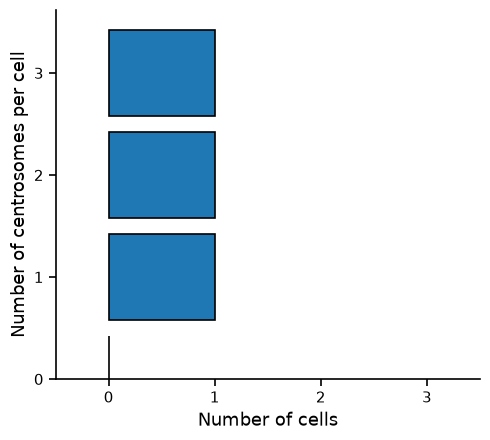

In [17]:
fig, ax = plt.subplots(figsize=(5, 4.5))

max_count = int(roi_counts.max())

# Bins centered on integers
bins = np.arange(-0.5, max_count + 1.5, 1)

ax.hist(
    roi_counts,
    bins=bins,
    orientation="horizontal",
    edgecolor="black",
    linewidth=1.2,
    rwidth=0.85
)

# Labels
ax.set_xlabel(
    "Number of cells",
    fontsize=13
)

ax.set_ylabel(
    "Number of centrosomes per cell",
    fontsize=13
)

# Integer ticks
ax.set_xticks(range(0, max_count + 1))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

# Tick appearance
ax.tick_params(
    axis="both",
    labelsize=11,
    width=1.2,
    length=5
)

# Cleaner frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# Start axes at zero
ax.set_xlim(-0.5, max_count + 0.5)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

In [16]:
roi_counts

Image                                                  Cell
2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma_tub-07  1       3
2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04             1       1
                                                       2       2
Name: ROI, dtype: int64